In [6]:
# from neko.core.network import Network
# from neko._visual.visualize_network import NetworkVisualizer
# import omnipath as op

import sys; sys.path += ['./../']
import numpy as np
import anndata as ad
import scanpy as sc
import matplotlib.pyplot as plt
import os

print(os.getcwd())

stim=1.0
prior=1.0

/Users/eventre/Documents/GitHub/CardamomOT/utils


In [7]:
def add_edges_from_matrix(network, inter_real, threshold=0.0, reg_max=5):
    """
    Ajoute des interactions à un objet network à partir d'une matrice d'interactions.

    Args:
        network: objet Neko network possédant .node et .add_edge()
        inter_real: numpy.ndarray ou DataFrame carrée de taille GxG
        threshold: valeur absolue minimale du poids pour créer une interaction

    Returns:
        None
    """
    

    # Si c'est un DataFrame, on extrait la matrice numpy
    if isinstance(inter_real, pd.DataFrame):
        inter_real = inter_real.values

    # Récupérer les noms des gènes dans l'ordre des lignes/colonnes
    genes = list(network.nodes["Genesymbol"])

    G = len(genes)
    assert inter_real.shape == (G, G), "La matrice inter_real doit être carrée et correspondre au nombre de gènes."

    for j in range(G):
        out_strength = np.abs(inter_real[:, j])  # outgoing regulation
        top_indices = np.argsort(out_strength)[::-1][:reg_max]
        for i in range(G):
            val = inter_real[i, j]
            if abs(val) > threshold and i in top_indices:  # filtrage optionnel
                # Déterminer le type d’interaction
                if val > 0:
                    interaction_type = "stimulation"
                elif val < 0:
                    interaction_type = "inhibition"
                else:
                    continue  # aucune interaction
                
                # Créer le DataFrame au format attendu par add_edge()
                edge_df = pd.DataFrame([{
                    "source": genes[i],
                    "target": genes[j],
                    "type": interaction_type,
                    "references": "inferred_from_matrix"
                }])
                
                # Ajouter l’interaction au réseau
                network.add_edge(edge_df)

    network.edges['Effect'] = network.edges['Type']

import pandas as pd
import networkx as nx

def analyse_reseau(matrix, gene_names=None, name="Réseau",
                   top_regulateurs=10, top_cibles=10, width_scale=5):
    """
    Analyse et visualise un réseau à partir de sa matrice d'adjacence.
    - matrix : np.ndarray ou pd.DataFrame, intensité i->j (peut être négative pour inhibition)
    - gene_names : liste de noms de gènes
    - width_scale : facteur multiplicatif pour l'épaisseur des flèches
    """

    matrix -= np.diag(np.diag(matrix))

    # --- Préparation ---
    if isinstance(matrix, np.ndarray):
        matrix = pd.DataFrame(matrix)
    n = matrix.shape[0]

    if gene_names is None or len(gene_names) != n:
        gene_names = [f"G{i}" for i in range(n)]
    matrix.index = matrix.columns = gene_names

    # Score sortant (régulateur fort = somme absolue)
    score_sortant = matrix.abs().sum(axis=1)
    top_regs = score_sortant.nlargest(top_regulateurs).index

    # Échelle globale pour les largeurs
    max_intensity = matrix.abs().max().max()
    if max_intensity == 0:
        max_intensity = 1  # éviter division par 0

    toggle_edges_all = []
    subgraphs = []

    # --- Construction des sous-graphes ---
    for reg in top_regs:
        G = nx.DiGraph()
        series = matrix.loc[reg]  # série des intensités reg -> *
        # <-- Correction: on prend d'abord les indices par |valeur| puis on récupère les signes -->
        top_idx = series.abs().nlargest(top_cibles).index
        top_targets = series.loc[top_idx]
        for cible, intensite in top_targets.items():
            if intensite != 0:
                G.add_edge(reg, cible, weight=float(intensite))
                # toggle ? si la direction inverse est non nulle
                if matrix.loc[cible, reg] != 0:
                    toggle_edges_all.append((reg, cible))
        subgraphs.append(G)

    # --- Affichage des sous-graphes ---
    ncols = 5
    nrows = int(np.ceil(len(subgraphs) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(18, 3*nrows))
    axes = axes.flatten()

    for i, (G, reg) in enumerate(zip(subgraphs, top_regs)):
        ax = axes[i]
        pos = nx.spring_layout(G, seed=42)
        nx.draw_networkx_nodes(G, pos, node_size=800, node_color="lightblue", ax=ax)
        nx.draw_networkx_labels(G, pos, font_size=9, ax=ax)

        # Arêtes séparées selon le signe
        edges_pos = [(u, v, d['weight']) for u, v, d in G.edges(data=True) if d['weight'] > 0]
        edges_neg = [(u, v, d['weight']) for u, v, d in G.edges(data=True) if d['weight'] < 0]

        # Largeurs proportionnelles à |intensité|
        widths_pos = [abs(w) / max_intensity * width_scale for (_, _, w) in edges_pos]
        widths_neg = [abs(w) / max_intensity * width_scale for (_, _, w) in edges_neg]

        if edges_pos:
            nx.draw_networkx_edges(G, pos,
                                   edgelist=[(u, v) for (u, v, _) in edges_pos],
                                   edge_color="green", width=widths_pos, arrows=True, ax=ax)
        if edges_neg:
            nx.draw_networkx_edges(G, pos,
                                   edgelist=[(u, v) for (u, v, _) in edges_neg],
                                   edge_color="red", width=widths_neg, arrows=True, ax=ax)

        ax.set_title(f"{reg} (régulateur top #{i+1})", fontsize=10)
        ax.axis("off")

    # Supprimer cases vides (si il y en a)
    total = len(subgraphs)
    for j in range(total, len(axes)):
        axes[j].axis("off")

    # plt.suptitle(f"{name} — Top {top_regulateurs} régulateurs "
    #              "(vert=activation, rouge=inhibition, épaisseur=intensité)",
    #              fontsize=13)
    plt.tight_layout()
    plt.show()

def reseau_top_regulateurs(
        matrix,
        gene_names=None,
        name="Réseau réduit top régulateurs",
        top_regulators=10,
        top_targets_per_reg=8,
        leaf_threshold=0.0,
        width_scale=5
):
    """
    Construit un réseau réduit où :
    - seuls les top régulateurs ont des arêtes sortantes,
    - ils pointent vers leurs cibles les plus fortes,
    - les cibles ne génèrent AUCUNE arête sortante.

    leaf_threshold : seuil minimal (fraction du max absolu) pour inclure une cible comme feuille.
    """

    matrix = matrix.copy()
    matrix -= np.diag(np.diag(matrix))

    if isinstance(matrix, np.ndarray):
        matrix = pd.DataFrame(matrix)

    n = matrix.shape[0]
    if gene_names is None or len(gene_names) != n:
        gene_names = [f"G{i}" for i in range(n)]
    matrix.index = matrix.columns = gene_names

    # --- Scores sortants : qui sont les régulateurs forts ---
    score_sortant = matrix.abs().sum(axis=1)
    top_regs = list(score_sortant.nlargest(top_regulators).index)

    # Intensité max
    max_intensity = matrix.abs().max().max()
    th_abs = leaf_threshold * max_intensity  # seuil absolu

    # --- Construction du graphe ---
    G = nx.DiGraph()

    for reg in top_regs:
        # seulement les cibles de ce régulateur
        series = matrix.loc[reg].abs().sort_values(ascending=False)

        # top cibles
        targets = series.iloc[:top_targets_per_reg]
        # appliquer le seuil
        targets = targets[targets >= th_abs]

        for cible in targets.index:
            w = matrix.loc[reg, cible]
            if w != 0:
                G.add_edge(reg, cible, weight=float(w))

    # --- Visualisation ---
    plt.figure(figsize=(14, 10))
    try:
        pos = nx.nx_agraph.graphviz_layout(G, prog="dot")
    except:
        pos = nx.spring_layout(G, seed=42)

    # Couleur : régulateur = bleu, cible = gris
    node_colors = ["skyblue" if n in top_regs else "lightgray" for n in G.nodes]

    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=900)
    nx.draw_networkx_labels(G, pos, font_size=9)

    # Arêtes
    edges_pos = [(u, v, d["weight"]) for u, v, d in G.edges(data=True) if d["weight"] > 0]
    edges_neg = [(u, v, d["weight"]) for u, v, d in G.edges(data=True) if d["weight"] < 0]

    wp = [abs(w) / max_intensity * width_scale for (_, _, w) in edges_pos]
    wn = [abs(w) / max_intensity * width_scale for (_, _, w) in edges_neg]

    if edges_pos:
        nx.draw_networkx_edges(G, pos,
                               edgelist=[(u, v) for (u, v, _) in edges_pos],
                               edge_color="green", width=wp, arrows=True)
    if edges_neg:
        nx.draw_networkx_edges(G, pos,
                               edgelist=[(u, v) for (u, v, _) in edges_neg],
                               edge_color="red", width=wn, arrows=True)

    plt.title(f"{name} — seuls les top régulateurs ont des arêtes sortantes", fontsize=14)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

    return G

def plot_networks_ref(p, seuil=.5):

    ref_path = f'{p}/cardamom/ref_network.csv'

    # 1️⃣ Charger la matrice complète depuis le CSV
    ref_df = pd.read_csv(ref_path, index_col=0)
    # 2️⃣ S’assurer que les noms des colonnes sont bien des chaînes
    ref_df.columns = ref_df.columns.astype(str)
    ref_df.index = ref_df.index.astype(str)
    # 3️⃣ Filtrer les gènes présents à la fois dans ref_df et ta liste
    # 4️⃣ Extraire la sous-matrice dans le bon ordre (ligne + colonne)
    sub_df = ref_df.loc[ref_df.index, ref_df.index]
    # 5️⃣ Convertir en numpy array si besoin
    ref_mat = sub_df.to_numpy()

    network = Network(list(ref_df.index), resources = 'omnipath')
    genes_final = list(network.nodes['Genesymbol'])
    mask = []
    genes_init_final = []
    for cnt, g in enumerate(ref_df.index):
        if g in genes_final:
            mask.append(cnt)
            genes_init_final.append(g)

    network = Network(genes_init_final, resources = 'omnipath')
    ref_plot = ref_mat[mask, :][:, mask]
    add_edges_from_matrix(network, ref_plot, threshold=0.1)
    visualizer = NetworkVisualizer(network, color_by='type', noi=True)
    visualizer.render()

def plot_networks(p, stim, prior, seuil=.3, reg_max = 5, network=1, train="train"):
    adata_path = f'{p}/Data/data_{train}.h5ad'
    adata = sc.read_h5ad(adata_path)

    grn_path = f'{p}/cardamom/inter_simul.npy'
    grn_mat = np.load(grn_path)[1:, 1:]

    genes_init = list(adata.var_names)

    if network:
        network = Network(genes_init, resources = 'omnipath')
        genes_final = list(network.nodes['Genesymbol'])
        mask = []
        genes_init_final = []
        for cnt, g in enumerate(genes_init):
            if g in genes_final:
                mask.append(cnt)
                genes_init_final.append(g)

        network = Network(genes_init_final, resources = 'omnipath')
        print(len(mask), grn_mat.shape)
        grn_plot = grn_mat[mask, :, 0][:, mask]
        add_edges_from_matrix(network, grn_plot, threshold=seuil, reg_max=reg_max)
        visualizer = NetworkVisualizer(network, color_by='type', noi=True)
        visualizer.render()
        analyse_reseau(grn_plot, genes_init_final)
    else:
        analyse_reseau(grn_mat[:, :, 0], genes_init, top_regulateurs=1000)
        reseau_top_regulateurs(
        grn_mat[:, :, 0],
        gene_names=genes_init,
        name="Réseau réduit",
        top_regulators=10,
        leaf_threshold=0.01,
        width_scale=5,
)


In [8]:
def plot_networks(p, stim, prior, seuil=.3, reg_max = 5, network=1, train="train"):
    adata_path = f'{p}/Data/data_{train}.h5ad'
    adata = sc.read_h5ad(adata_path)

    grn_path = f'{p}/cardamomOT/inter_simul.npy'
    grn_mat = np.load(grn_path)[1:, 1:]

    genes_init = list(adata.var_names)

    analyse_reseau(grn_mat[:, :, 0], genes_init, top_regulateurs=1000)
    reseau_top_regulateurs(
    grn_mat[:, :, 0],
    gene_names=genes_init,
    name="Réseau réduit",
    top_regulators=10,
    leaf_threshold=0.01,
    width_scale=5,
)

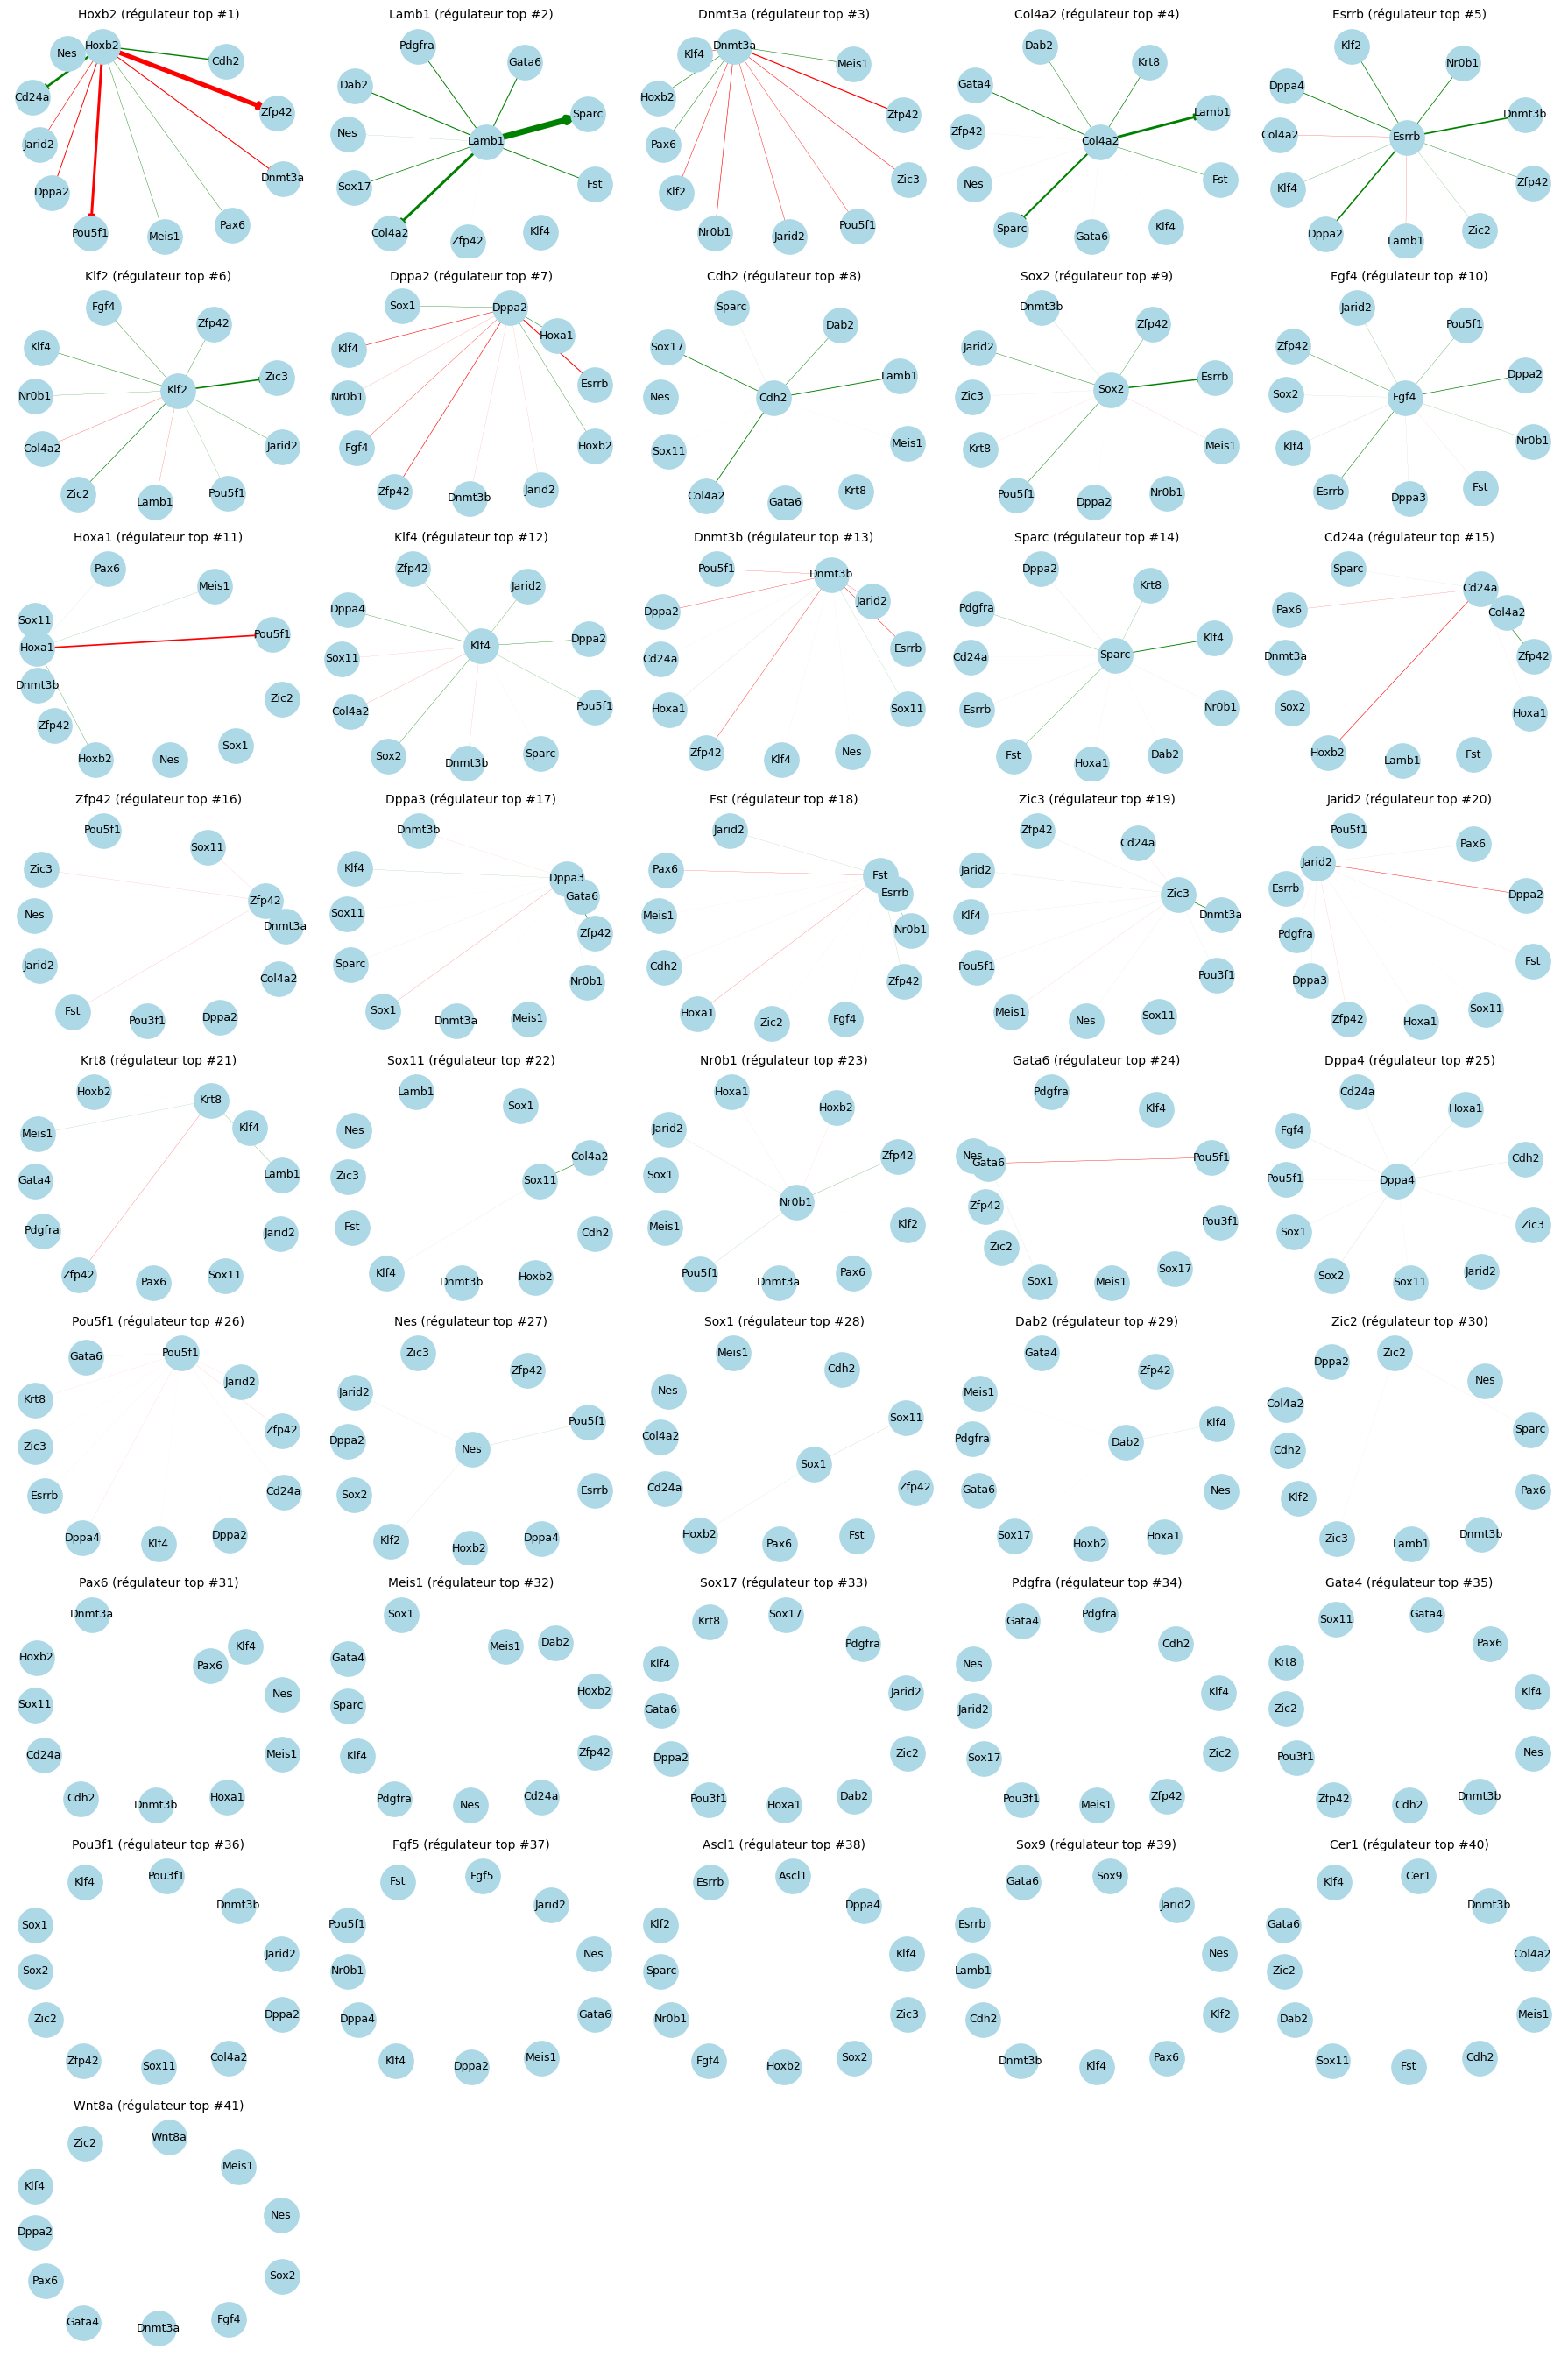

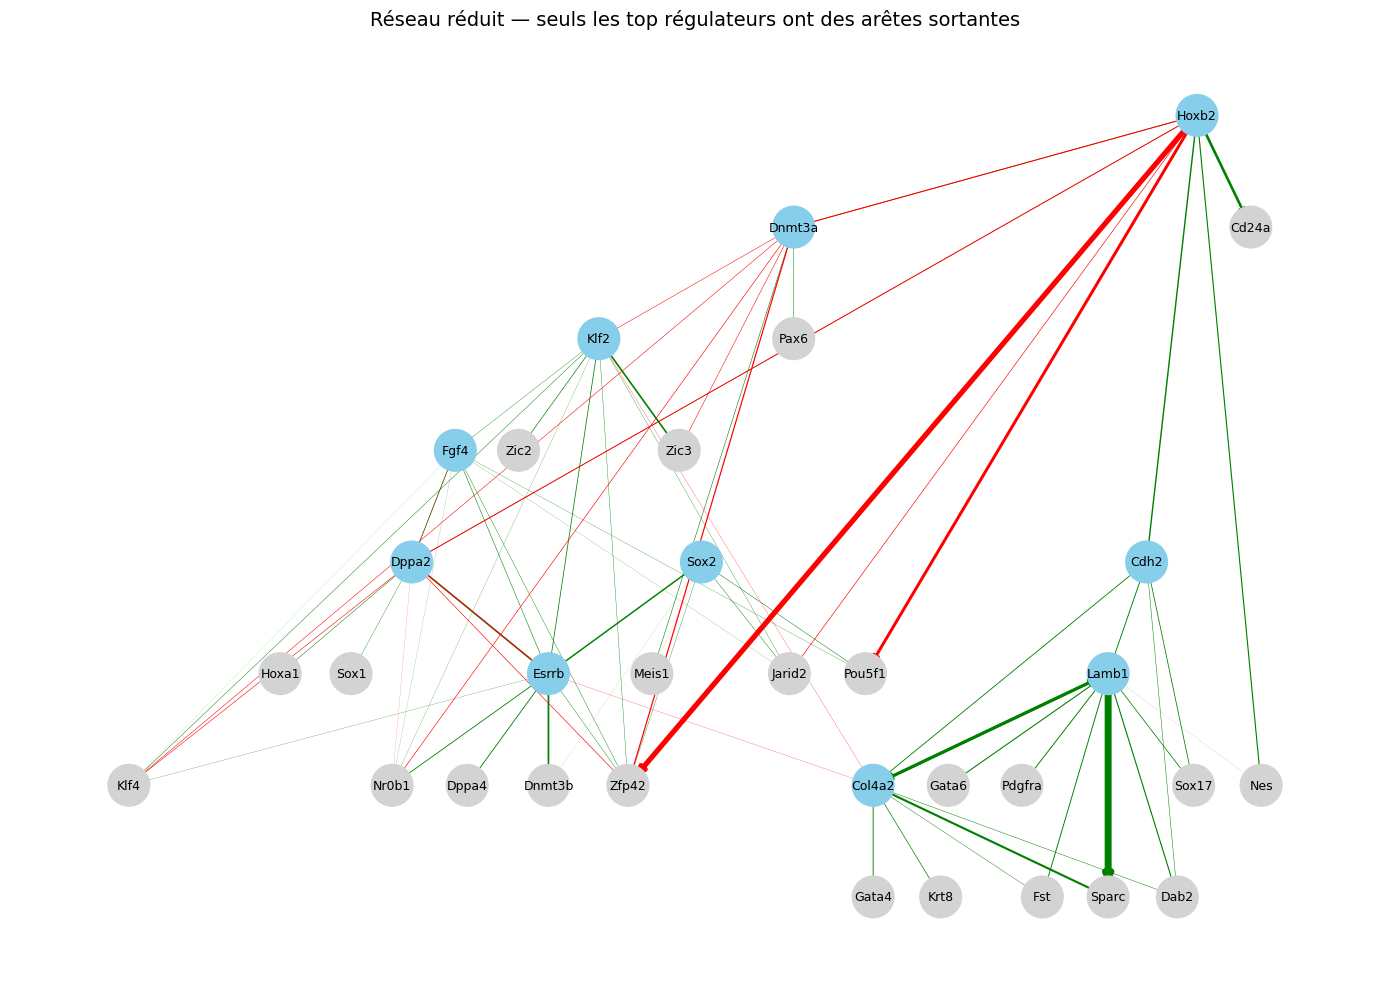

In [9]:
p = './../experimental_datasets/Semrau'

plot_networks(p, stim, prior, seuil=2, network=0, train="full")

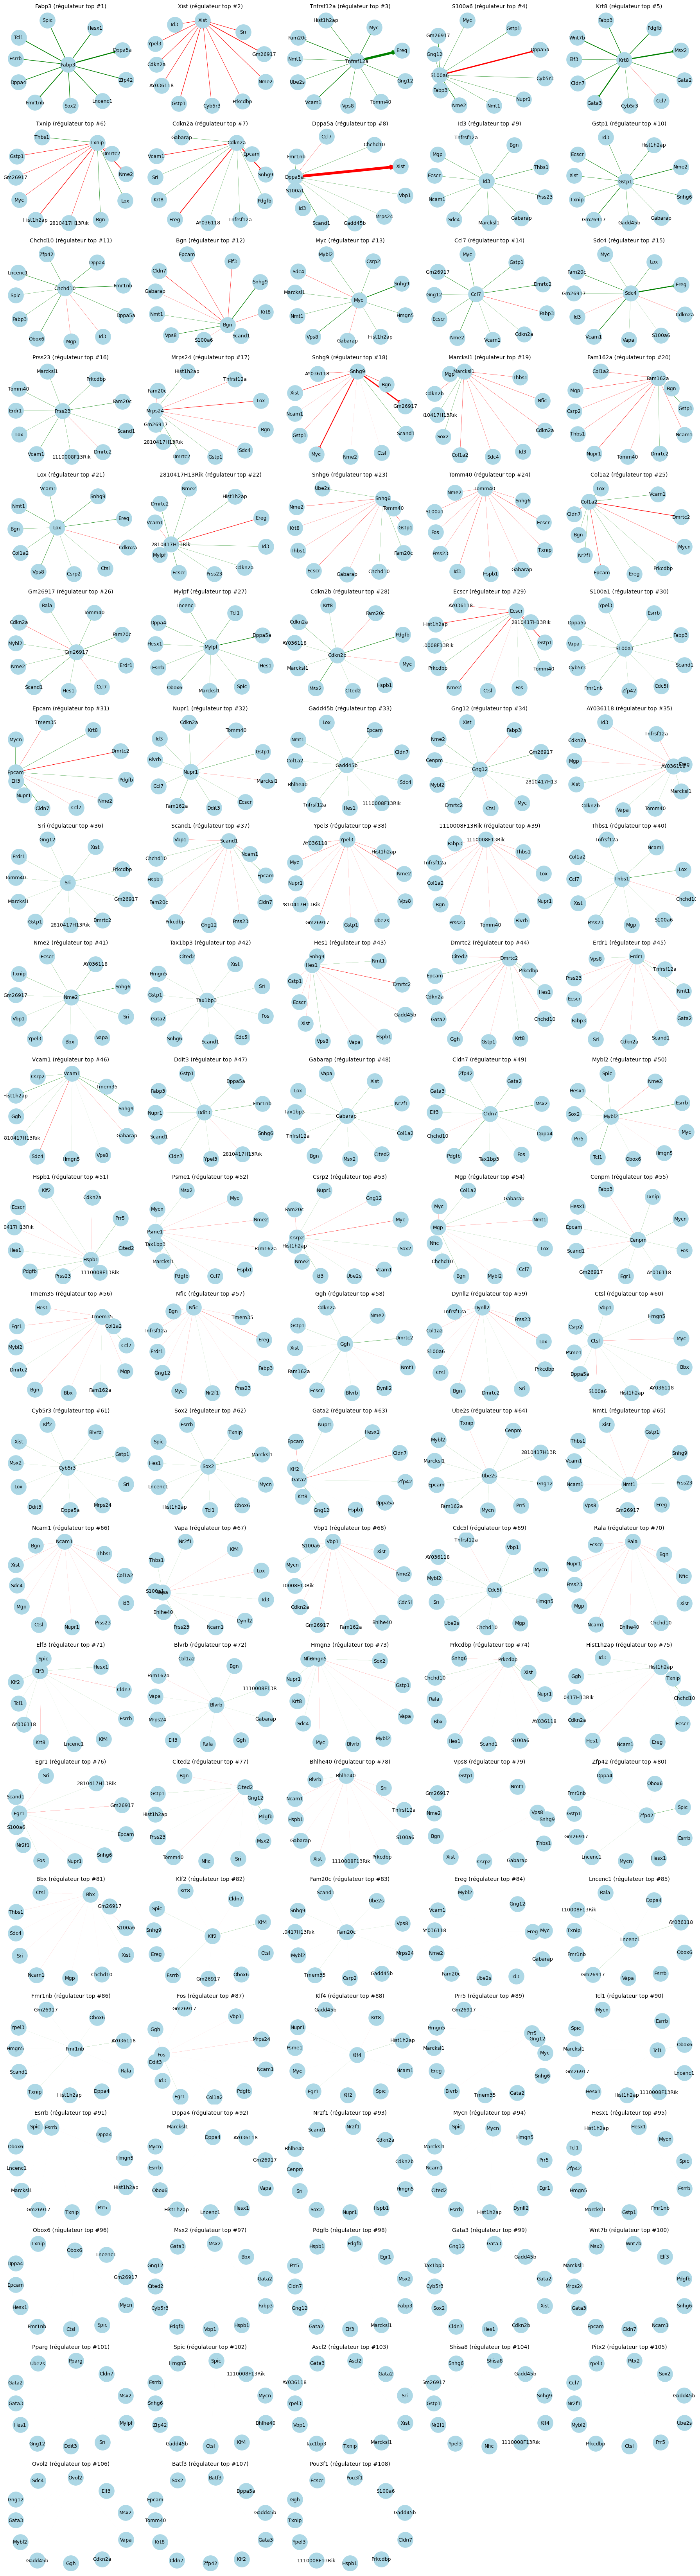

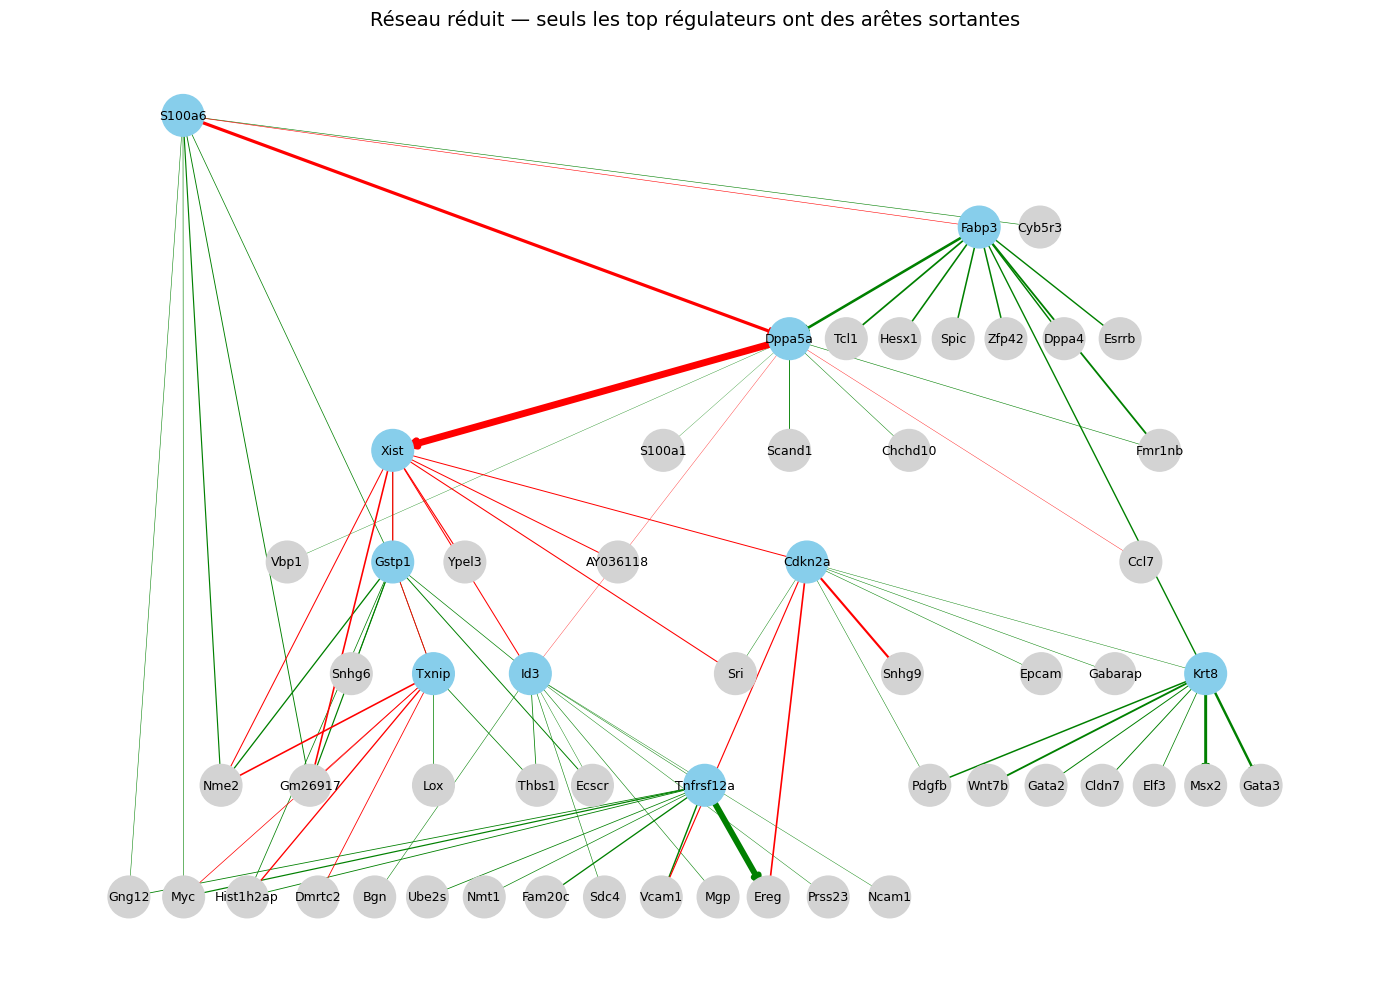

In [12]:
p = './../experimental_datasets/Schiebinger'

plot_networks(p, stim, prior, seuil=2, network=0, train='train')

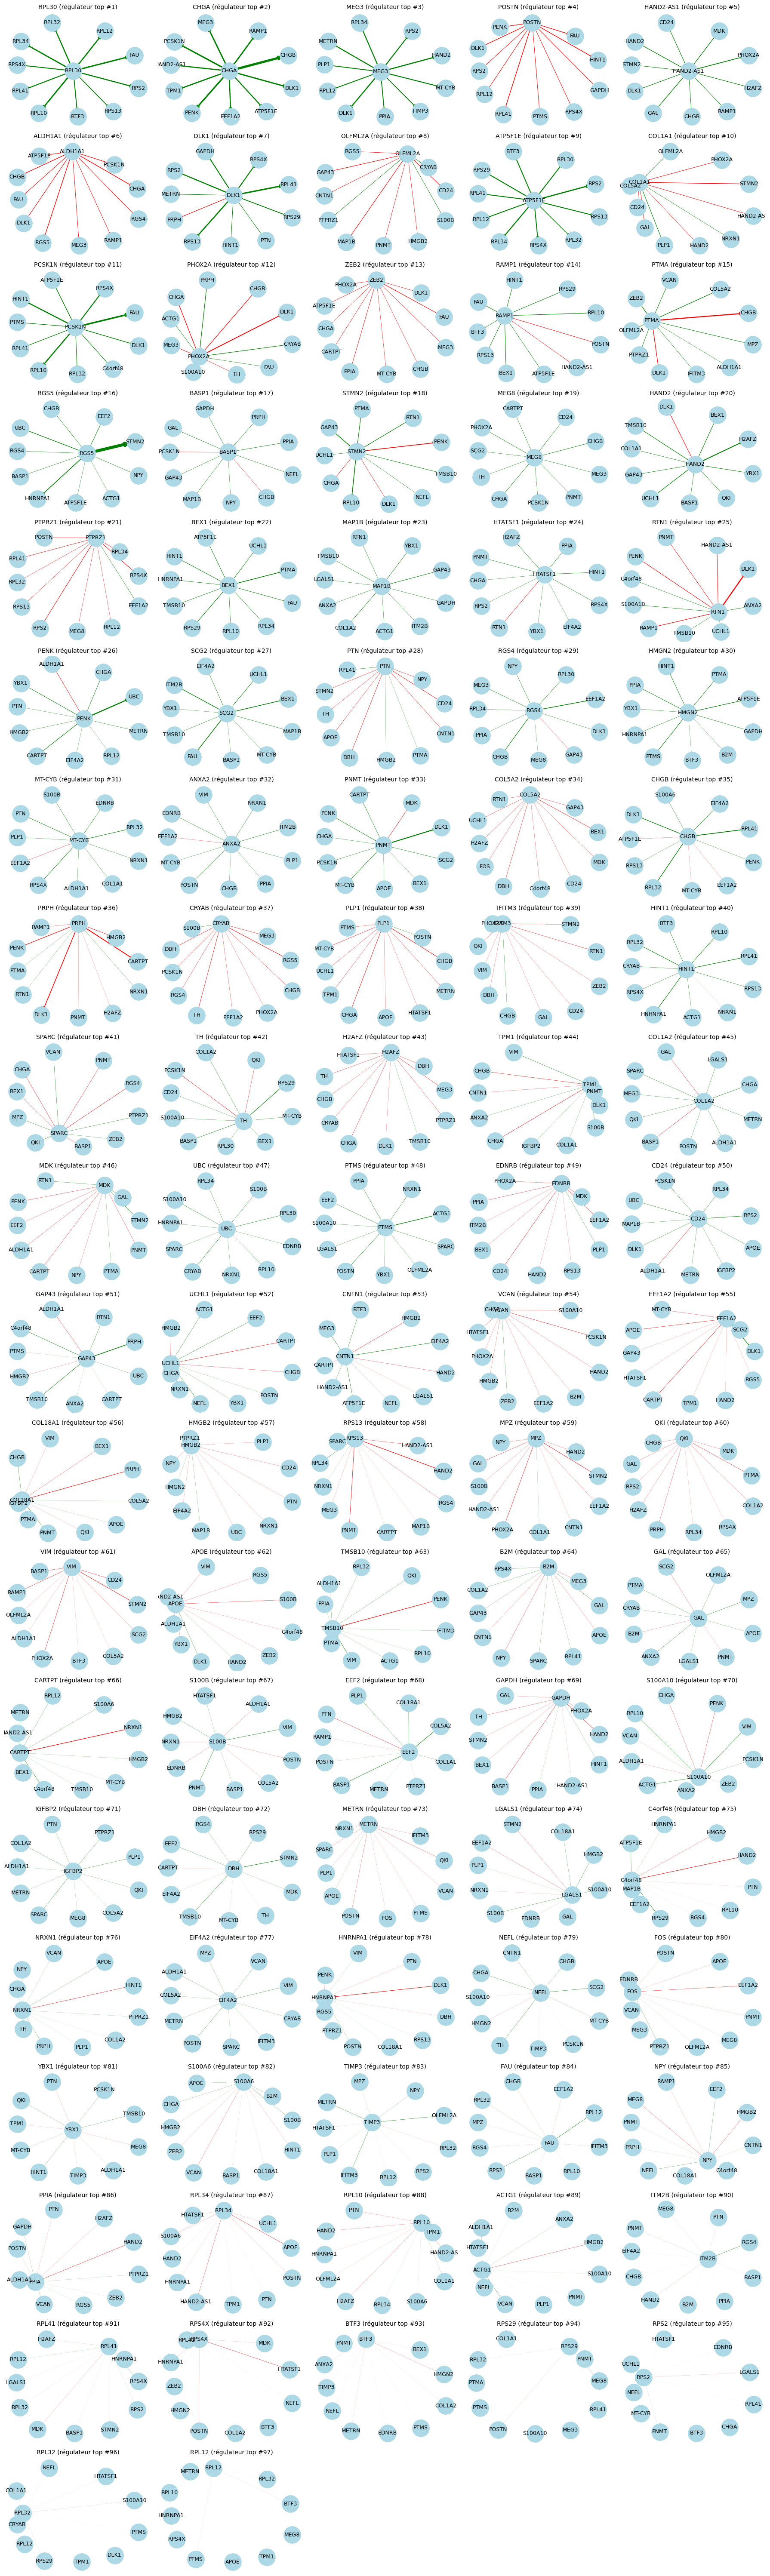

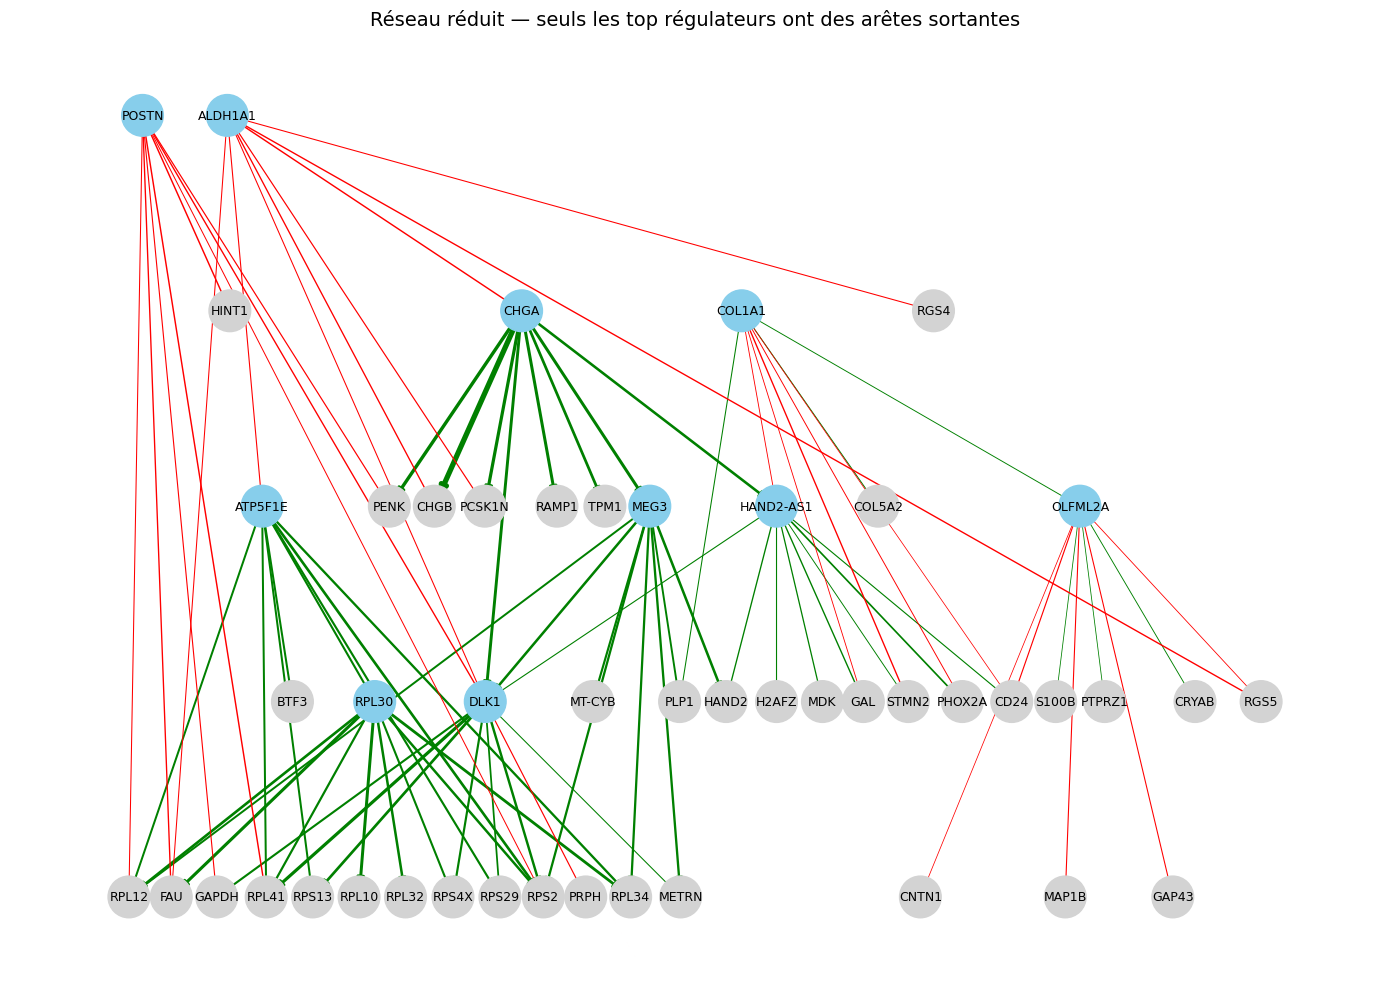

In [11]:
p = './../experimental_datasets/Kameneva'

plot_networks(p, stim, prior, seuil=2, network=0, train="full")